BINARY CLASSIFICATION

for binary classfication we change our activation function and also our loss function 
we use a sigmoid activation function and change our loss function to binary cross entropy loss 


In [26]:
import numpy as np 
import torch 
import torch.nn as nn 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


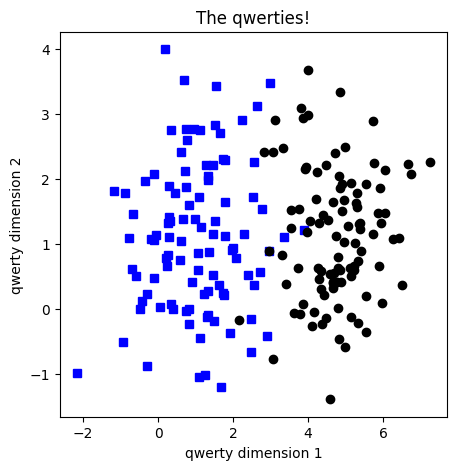

In [45]:
# create data

nPerClust = 100
blur = 1

A = [  1, 1 ]
B = [  5, 1 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

1.nPerClust = 100 , Number of points per cluster.

2.blur = 1 , it decides how spread out the points are , if blur = 0 all points would be at the same spot 

3.A = [1,1]
  B = [5,1]
These define the centers of two clusters.Thus their centers are horizontally apart 




In [46]:
#creating the model 
model = nn.Sequential(
    nn.Linear(2,10),
    nn.ReLU(),
    nn.Linear(10,1),
    nn.Sigmoid()
   )



In [47]:
#now we need to train the model and define the loss function and the optimizer
lossfun=nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)   

'''
Problems With Pure SGD

1️.Slow convergence - SGD can move very slowly toward the minimum.

2.If learning rate is:
   Too small → training is very slow
   Too large → training becomes unstable
   
3.gets stuck in flat regions

Why People Often Use Adam Instead ??
Feature	                   SGD	           Adam
1.Convergence speed	       slower	       faster
2.Learning rate tuning	   harder          easier
3.Stability	               lower	       higher
4.Default choice today	   less common     very common

'''




'\nProblems With Pure SGD\n\n1️.Slow convergence - SGD can move very slowly toward the minimum.\n\n2.If learning rate is:\n   Too small → training is very slow\n   Too large → training becomes unstable\n   \n3.gets stuck in flat regions\n\nWhy People Often Use Adam Instead ??\nFeature\t                   SGD\t           Adam\n1.Convergence speed\t       slower\t       faster\n2.Learning rate tuning\t   harder          easier\n3.Stability\t               lower\t       higher\n4.Default choice today\t   less common     very common\n\n'

In [48]:
# training the model 
epochs = 300
losses = []
for i in range(epochs):
    #forward prop 
    y_preds=model(data)
    
    #calculating loss 
    loss=lossfun(y_preds,labels)
    losses.append(loss.item())
    
    #back prop 
    optimizer.zero_grad() #this is important to prevent accumulation of gradients
    loss.backward()
    optimizer.step() #this is where the weights are updated
    
    

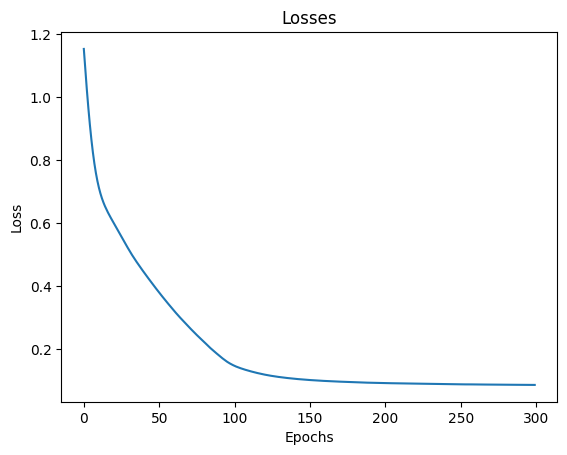

In [49]:
#plotting the losses 
sns.lineplot(x=range(len(losses)), y=losses)
plt.title('Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


In [50]:
# compute the predictions

predlabels = y_preds>.5

# find errors
misclassified = np.where(predlabels != labels)[0]

# total accuracy
totalacc = 100-100*len(misclassified)/(2*nPerClust)

print('Final accuracy: %g%%' %totalacc)


Final accuracy: 97.5%


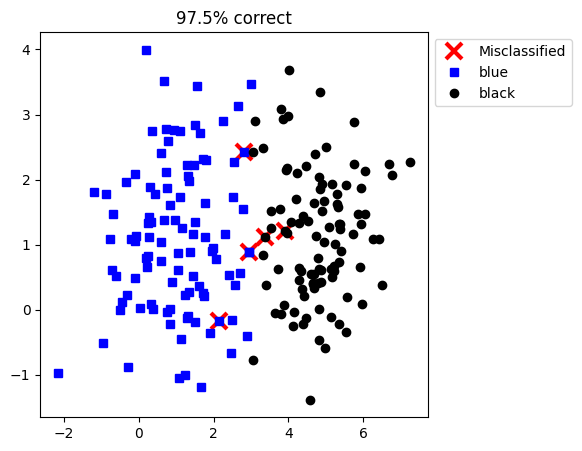

In [51]:
# plot the labeled data
fig = plt.figure(figsize=(5,5))
plt.plot(data[misclassified,0] ,data[misclassified,1],'rx',markersize=12,markeredgewidth=3)
plt.plot(data[np.where(~predlabels)[0],0],data[np.where(~predlabels)[0],1],'bs')
plt.plot(data[np.where(predlabels)[0],0] ,data[np.where(predlabels)[0],1] ,'ko')

plt.legend(['Misclassified','blue','black'],bbox_to_anchor=(1,1))
plt.title(f'{totalacc}% correct')
plt.show()

What happens if we remove the non linearity i.e the ReLU activation function . How does the model changes 


In [52]:
model2=nn.Sequential(
    nn.Linear(2 , 10),
    nn.Linear(10 , 1),
    nn.Sigmoid()
    )
lossfun=nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)  
losses2=[] 
#training the model 
# training the model 
epochs = 300
losses = []
for i in range(epochs):
    #forward prop 
    y_preds=model(data)
    
    #calculating loss 
    loss=lossfun(y_preds,labels)
    losses.append(loss.item())
    
    #back prop 
    optimizer.zero_grad() #this is important to prevent accumulation of gradients
    loss.backward()
    optimizer.step() #this is where the weights are updated
    
    

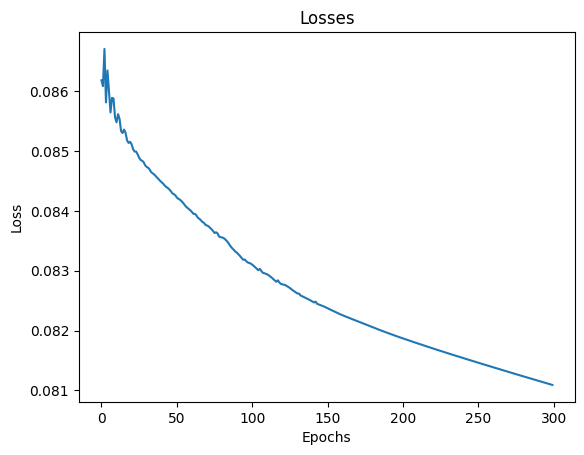

In [53]:
#plotting the losses 
sns.lineplot(x=range(len(losses)), y=losses)
plt.title('Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


Final accuracy: 97%


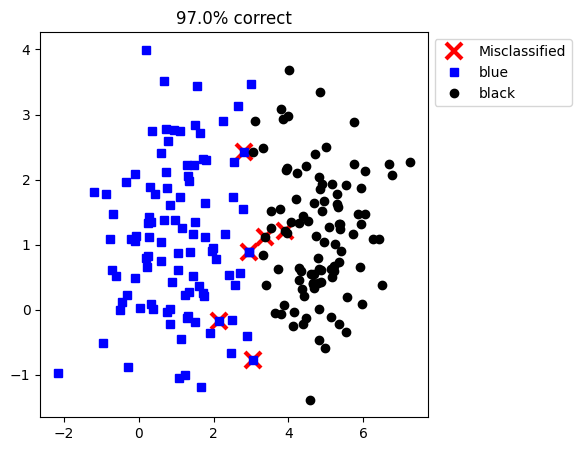

In [54]:
# compute the predictions
predlabels2 = y_preds>.5
# find errors
misclassified2 = np.where(predlabels2 != labels)[0]
# total accuracy
totalacc2 = 100-100*len(misclassified2)/(2*nPerClust)
print('Final accuracy: %g%%' %totalacc2)

# plot the labeled data
fig = plt.figure(figsize=(5,5))
plt.plot(data[misclassified2,0] ,data[misclassified2,1],'rx',markersize=12,markeredgewidth=3)
plt.plot(data[np.where(~predlabels2)[0],0],data[np.where(~predlabels2)[0],1],'bs')
plt.plot(data[np.where(predlabels2)[0],0] ,data[np.where(predlabels2)[0],1] ,'ko')

plt.legend(['Misclassified','blue','black'],bbox_to_anchor=(1,1))
plt.title(f'{totalacc2}% correct')
plt.show()

**Inference from this experiment**

1.Simple datasets require simple solutions . They are often the best solutions with very less computation 

2.If a dataset have features which are linearly separable then it will outperform the model which is non linear. Adding non linearity forces the model to search for more complex patterns which are actually not present in a simple dataset

3.Dont just train a very complex model to a simple dataset just because you can 
